# Episode VII — Horizon of Depth

**Deep Learning from Scratch** — A Guide for Self-Learners

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/Pchambet/Deep-Learning-from-Scratch/blob/main/notebooks/07_horizon_of_depth.ipynb)

---

In this notebook, we generalize our 2-layer neural network from Episode VI to **any number of layers**.

The key idea: replace hardcoded indices with loops. The code barely changes — but the power becomes infinite.

> *"Two layers was the beginning. Now we cross the horizon."*

## Setup

In [1]:
import sys
import os

# Auto-detect Colab and setup environment
if 'google.colab' in sys.modules:
    !git clone https://github.com/Pchambet/Deep-Learning-from-Scratch.git
    os.chdir('Deep-Learning-from-Scratch')
    !pip install -q h5py tqdm
    print('Colab setup complete.')
else:
    # Local: move to repo root if inside notebooks/
    if os.path.basename(os.getcwd()) == 'notebooks':
        os.chdir('..')

sys.path.insert(0, 'src')

In [2]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import make_circles, make_moons, make_blobs
from sklearn.metrics import log_loss, accuracy_score
from tqdm import tqdm

---

## 1. The Architecture List

In Episode VI, the architecture was defined by three separate numbers: `n0`, `n1`, `n2`.

Now we define the entire architecture with **a single list**:

```python
dimensions = [n0, n1, n2, ..., nL]
```

- `n0` = input dimension
- `n1, n2, ...` = hidden layer sizes
- `nL` = output dimension

The number of layers is `L = len(dimensions) - 1`.

**One list. Any architecture. Any depth.**

---

## 2. Initialization — The Loop

**Episode VI** (hardcoded for 2 layers):
```python
def initialisation(n0, n1, n2):
    parameters = {
        'W1': np.random.randn(n1, n0),
        'b1': np.random.randn(n1, 1),
        'W2': np.random.randn(n2, n1),
        'b2': np.random.randn(n2, 1),
    }
    return parameters
```

**Episode VII** (any number of layers):

In [3]:
def initialisation(dimensions):
    parameters = {}
    L = len(dimensions)
    for l in range(1, L):
        parameters[f'W{l}'] = np.random.randn(dimensions[l], dimensions[l-1])
        parameters[f'b{l}'] = np.random.randn(dimensions[l], 1)
    return parameters

In [4]:
# Test: 3-layer network (2 hidden + 1 output)
parameters = initialisation([2, 32, 32, 1])
for key, value in parameters.items():
    print(key, value.shape)

W1 (32, 2)
b1 (32, 1)
W2 (32, 32)
b2 (32, 1)
W3 (1, 32)
b3 (1, 1)


6 parameters instead of 4. Three layers instead of two. **Same function.**

---

## 3. Forward Propagation — The Generic Loop

For each layer $l$:
$$Z_l = W_l \cdot A_{l-1} + b_l \quad \text{then} \quad A_l = \sigma(Z_l)$$

We store all activations — we'll need them for backpropagation.

In [5]:
def forward_propagation(X, parameters):
    activations = {'A0': X}
    L = len(parameters) // 2
    A = X
    for l in range(1, L + 1):
        Z = parameters[f'W{l}'] @ A + parameters[f'b{l}']
        A = 1 / (1 + np.exp(-Z))
        activations[f'A{l}'] = A
    return activations

In [6]:
# Test with dummy data
X, y = make_blobs(n_samples=100, n_features=2, centers=2, random_state=0)
X = X.T
y = y.reshape((1, y.shape[0]))

print('X shape:', X.shape)
print('y shape:', y.shape)

activations = forward_propagation(X, parameters)
for key, value in activations.items():
    print(key, value.shape)

X shape: (2, 100)
y shape: (1, 100)
A0 (2, 100)
A1 (32, 100)
A2 (32, 100)
A3 (1, 100)


---

## 4. Generalized Backpropagation

The heart of the episode. The generalized equations:

**Output layer** ($l = L$):
$$dZ_L = A_L - y$$

**Hidden layers** ($l = L-1, \dots, 1$):
$$dZ_l = (W_{l+1}^T \cdot dZ_{l+1}) \odot A_l \odot (1 - A_l)$$

**All layers**:
$$dW_l = \frac{1}{m} \cdot dZ_l \cdot A_{l-1}^T \qquad db_l = \frac{1}{m} \sum dZ_l$$

In [7]:
def back_propagation(y, parameters, activations):
    m = y.shape[1]
    L = len(parameters) // 2

    # Output layer error
    dZ = activations[f'A{L}'] - y
    gradients = {}

    # Loop backward through the layers
    for l in reversed(range(1, L + 1)):
        gradients[f'dW{l}'] = 1/m * dZ @ activations[f'A{l-1}'].T
        gradients[f'db{l}'] = 1/m * np.sum(dZ, axis=1, keepdims=True)

        # If not the first layer, propagate error backward
        if l > 1:
            dA_prev = parameters[f'W{l}'].T @ dZ
            A_prev = activations[f'A{l-1}']
            dZ = dA_prev * A_prev * (1 - A_prev)  # sigmoid derivative

    return gradients

In [8]:
# Test backpropagation
gradients = back_propagation(y, parameters, activations)
for key, value in gradients.items():
    print(key, value.shape)

dW3 (1, 32)
db3 (1, 1)
dW2 (32, 32)
db2 (32, 1)
dW1 (32, 2)
db1 (32, 1)


---

## 5. Update & Predict

Almost identical to Episode VI — just loop over all $L$ layers.

In [9]:
def update(gradients, parameters, learning_rate):
    L = len(parameters) // 2
    for l in range(1, L + 1):
        parameters[f'W{l}'] -= learning_rate * gradients[f'dW{l}']
        parameters[f'b{l}'] -= learning_rate * gradients[f'db{l}']
    return parameters

In [10]:
def predict(X, parameters):
    activations = forward_propagation(X, parameters)
    L = len(parameters) // 2
    A = activations[f'A{L}']
    return A >= 0.5

---

## 6. The Training Loop

Structurally identical to Episode VI. But now it works for **any depth**.

In [11]:
def neural_network(X, y, dimensions, learning_rate, epoch):
    parameters = initialisation(dimensions)
    train_loss = []
    train_acc = []

    for i in tqdm(range(epoch)):
        L = len(parameters) // 2
        activations = forward_propagation(X, parameters)

        # Track metrics
        train_loss.append(log_loss(y.flatten(), activations[f'A{L}'].flatten()))
        predictions = predict(X, parameters)
        train_acc.append(accuracy_score(y.flatten(), predictions.flatten()))

        # Learn
        gradients = back_propagation(y, parameters, activations)
        parameters = update(gradients, parameters, learning_rate)

    # Plot
    plt.figure(figsize=(12, 4))
    plt.subplot(1, 2, 1)
    plt.plot(train_loss, label='Train Loss')
    plt.title('Learning Curve')
    plt.xlabel('Epochs')
    plt.ylabel('Loss')
    plt.legend()
    plt.subplot(1, 2, 2)
    plt.plot(train_acc, label='Train Accuracy')
    plt.title('Accuracy Curve')
    plt.xlabel('Epochs')
    plt.ylabel('Accuracy')
    plt.legend()
    plt.show()

    return parameters

### Decision Boundary Visualization

In [12]:
def decision_boundary(X, y, parameters):
    if X.shape[0] == 2:
        X_plot = X.T
    else:
        X_plot = X

    x_min, x_max = X_plot[:, 0].min() - 1, X_plot[:, 0].max() + 1
    y_min, y_max = X_plot[:, 1].min() - 1, X_plot[:, 1].max() + 1
    xx, yy = np.meshgrid(np.arange(x_min, x_max, 0.01),
                         np.arange(y_min, y_max, 0.01))

    grid = np.c_[xx.ravel(), yy.ravel()]
    Z = predict(grid.T, parameters)
    Z = Z.reshape(xx.shape)

    plt.contourf(xx, yy, Z, alpha=0.8, cmap='RdYlBu')
    plt.scatter(X_plot[:, 0], X_plot[:, 1], c=y.flatten(), edgecolors='k',
                marker='o', cmap='RdYlBu')
    plt.title('Decision Boundary')
    plt.xlabel('Feature 1')
    plt.ylabel('Feature 2')
    plt.show()

---

## 7. Testing Ground — Circles

Let's start where Episode VI left off.

X shape: (2, 100)
y shape: (1, 100)


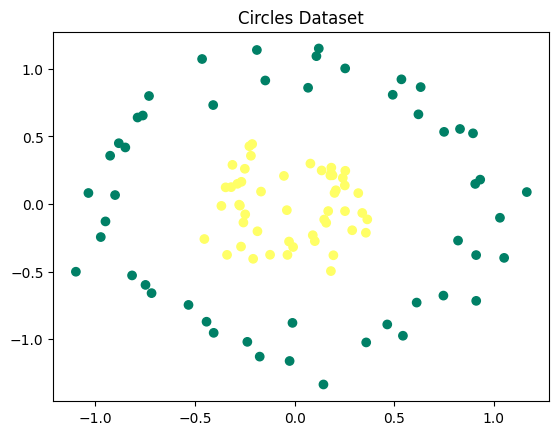

In [13]:
X, y = make_circles(n_samples=100, noise=0.1, factor=0.3, random_state=0)
X = X.T
y = y.reshape((1, y.shape[0]))

print('X shape:', X.shape)
print('y shape:', y.shape)

plt.scatter(X[0, :], X[1, :], c=y.flatten(), cmap='summer')
plt.title('Circles Dataset')
plt.show()

  0%|          | 0/500 [00:00<?, ?it/s]

 33%|███▎      | 164/500 [00:00<00:00, 1632.07it/s]

 66%|██████▌   | 328/500 [00:00<00:00, 1435.05it/s]

 95%|█████████▍| 474/500 [00:00<00:00, 1315.78it/s]

100%|██████████| 500/500 [00:00<00:00, 1280.55it/s]

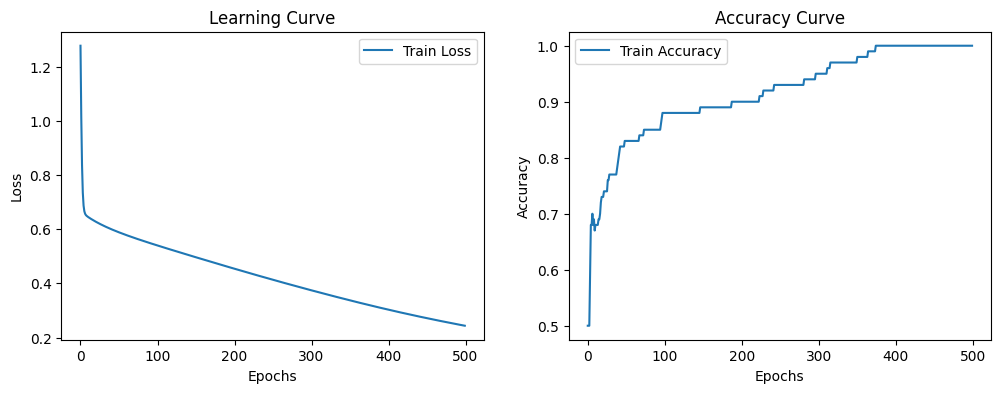

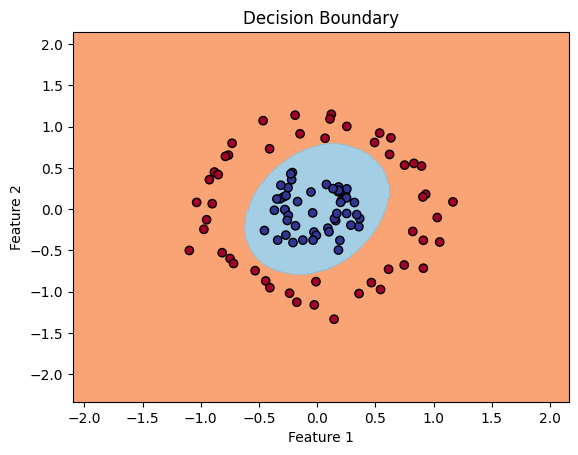

In [14]:
parameters = neural_network(X, y, [2, 32, 32, 1],
                            learning_rate=0.1, epoch=500)
decision_boundary(X, y, parameters)

~100% accuracy. Same as Episode VI, but now with a 3-layer architecture.

---

## 8. Testing Ground — Moons

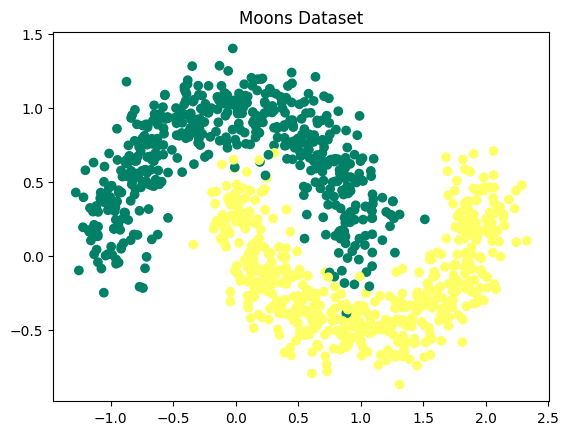

In [15]:
X, y = make_moons(n_samples=1000, noise=0.15, random_state=0)
X = X.T
y = y.reshape((1, y.shape[0]))

plt.scatter(X[0, :], X[1, :], c=y.flatten(), cmap='summer')
plt.title('Moons Dataset')
plt.show()

  0%|          | 0/5000 [00:00<?, ?it/s]

  1%|          | 60/5000 [00:00<00:08, 593.40it/s]

  2%|▏         | 123/5000 [00:00<00:07, 613.15it/s]

  4%|▎         | 185/5000 [00:00<00:08, 591.75it/s]

  5%|▍         | 249/5000 [00:00<00:07, 607.82it/s]

...

 96%|█████████▌| 4787/5000 [00:07<00:00, 496.27it/s]

 97%|█████████▋| 4849/5000 [00:08<00:00, 526.37it/s]

 98%|█████████▊| 4911/5000 [00:08<00:00, 550.33it/s]

 99%|█████████▉| 4973/5000 [00:08<00:00, 568.70it/s]

100%|██████████| 5000/5000 [00:08<00:00, 604.02it/s]

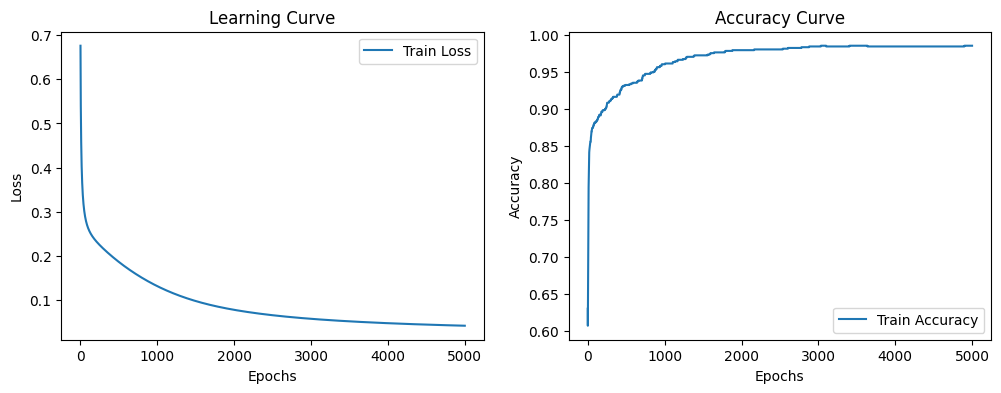

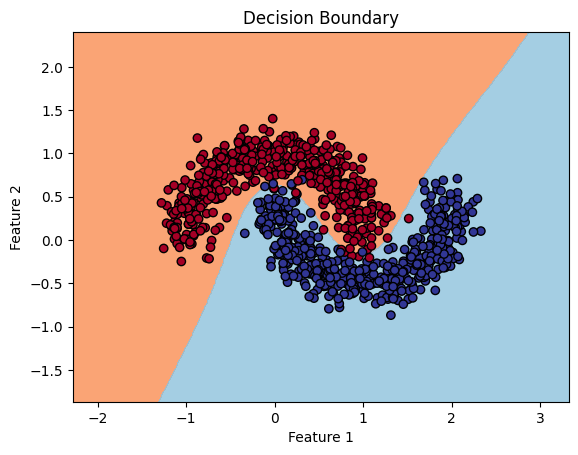

In [16]:
parameters = neural_network(X, y, [2, 64, 64, 1],
                            learning_rate=0.1, epoch=5000)
decision_boundary(X, y, parameters)

---

## 9. Testing Ground — Spirals

The real test. Spirals are interleaved — the two classes wrap around each other.

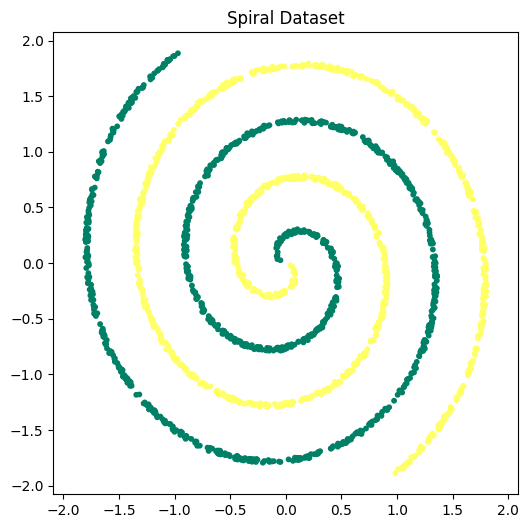

In [17]:
def make_spirals(n_samples=1000, noise=0.2, normalize=True):
    theta = np.sqrt(np.random.rand(n_samples, 1)) * 780 * (2 * np.pi / 360)

    x1 = -np.cos(theta) * theta + np.random.rand(n_samples, 1) * noise
    y1 =  np.sin(theta) * theta + np.random.rand(n_samples, 1) * noise
    spiral1 = np.hstack((x1, y1))

    x2 =  np.cos(theta) * theta + np.random.rand(n_samples, 1) * noise
    y2 = -np.sin(theta) * theta + np.random.rand(n_samples, 1) * noise
    spiral2 = np.hstack((x2, y2))

    X = np.vstack((spiral1, spiral2)).T
    y = np.hstack((np.zeros(n_samples), np.ones(n_samples)))
    y = y.reshape(1, -1)

    if normalize:
        X = (X - np.mean(X, axis=1, keepdims=True)) / np.std(X, axis=1, keepdims=True)

    return X, y

X, y = make_spirals(n_samples=1000, noise=0.2)

plt.figure(figsize=(6, 6))
plt.scatter(X[0], X[1], c=y.flatten(), cmap='summer', s=10)
plt.title('Spiral Dataset')
plt.axis('equal')
plt.show()

  0%|          | 0/5000 [00:00<?, ?it/s]

  0%|          | 25/5000 [00:00<00:20, 245.22it/s]

  1%|          | 51/5000 [00:00<00:19, 250.10it/s]

  2%|▏         | 77/5000 [00:00<00:19, 252.01it/s]

  2%|▏         | 103/5000 [00:00<00:19, 251.38it/s]

...

 98%|█████████▊| 4915/5000 [00:20<00:00, 243.57it/s]

 99%|█████████▉| 4940/5000 [00:20<00:00, 243.14it/s]

 99%|█████████▉| 4965/5000 [00:20<00:00, 224.46it/s]

100%|█████████▉| 4988/5000 [00:20<00:00, 225.04it/s]

100%|██████████| 5000/5000 [00:20<00:00, 241.97it/s]

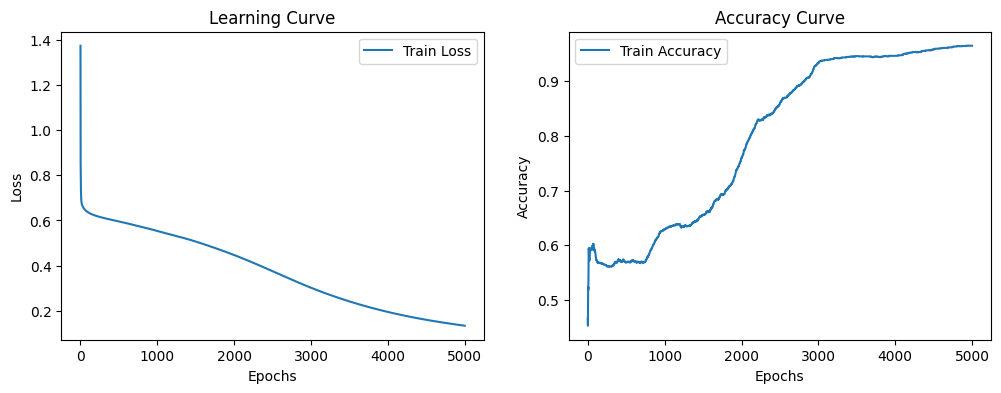

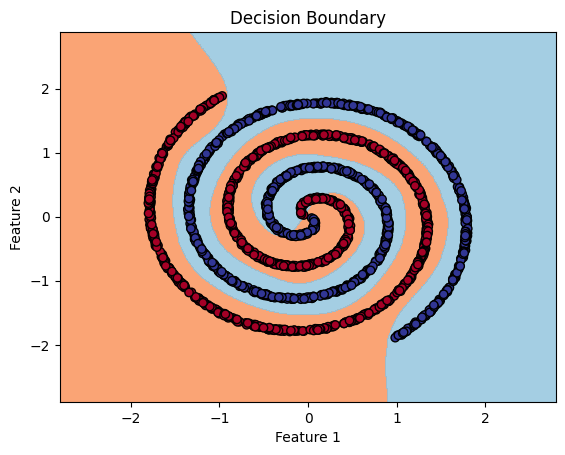

In [18]:
# 3 hidden layers
parameters = neural_network(X, y, [2, 64, 64, 64, 1],
                            learning_rate=0.1, epoch=5000)
decision_boundary(X, y, parameters)

  0%|          | 0/5000 [00:00<?, ?it/s]

  0%|          | 10/5000 [00:00<00:52, 94.76it/s]

  0%|          | 20/5000 [00:00<00:51, 96.09it/s]

  1%|          | 30/5000 [00:00<00:51, 96.46it/s]

  1%|          | 40/5000 [00:00<00:51, 96.58it/s]

...

 99%|█████████▉| 4967/5000 [00:53<00:00, 92.34it/s]

100%|█████████▉| 4977/5000 [00:53<00:00, 92.29it/s]

100%|█████████▉| 4987/5000 [00:53<00:00, 92.22it/s]

100%|█████████▉| 4997/5000 [00:54<00:00, 92.20it/s]

100%|██████████| 5000/5000 [00:54<00:00, 92.45it/s]

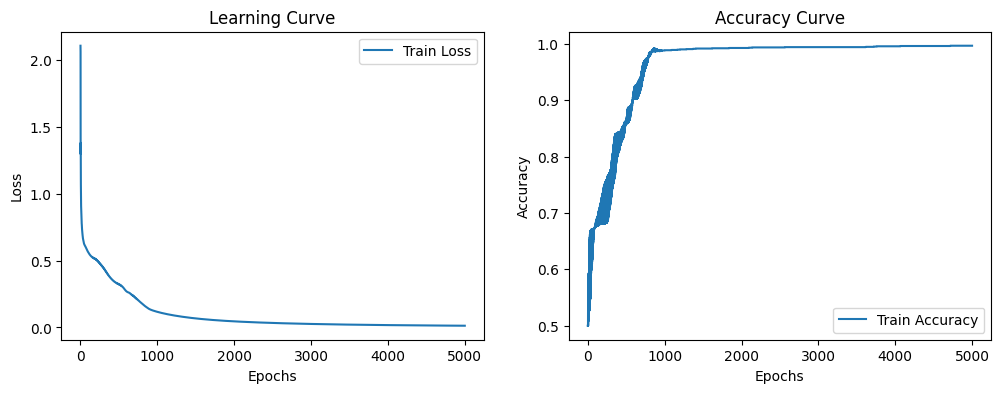

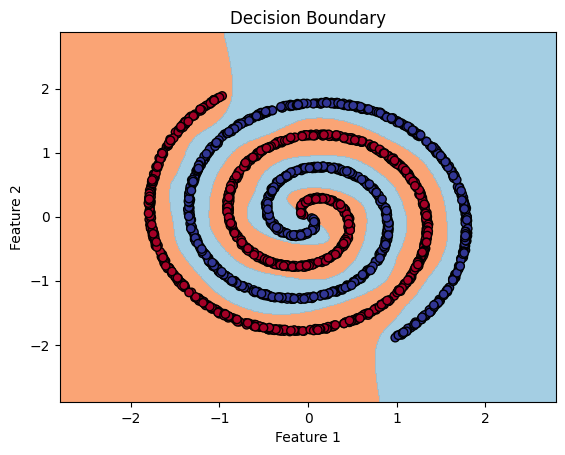

In [19]:
# Going deeper: 4 hidden layers with more neurons
parameters = neural_network(X, y, [2, 128, 128, 128, 128, 1],
                            learning_rate=0.1, epoch=5000)
decision_boundary(X, y, parameters)

More layers, more neurons — the decision boundary wraps tighter around the spiral arms.

**More complex data requires more depth. That's the whole point.**

---

## 10. Real Data — Cats vs Dogs

Let's go back to real images. Same data as Episode VI.

In [20]:
from utilities import load_data

X_train, y_train, X_test, y_test = load_data()

X_train_flat = X_train.reshape(64*64, -1) / 255.0
X_test_flat = X_test.reshape(64*64, -1) / 255.0
y_train = y_train.T
y_test = y_test.T

print('X_train shape:', X_train_flat.shape)
print('y_train shape:', y_train.shape)
print('X_test shape:', X_test_flat.shape)
print('y_test shape:', y_test.shape)

X_train shape: (4096, 1000)
y_train shape: (1, 1000)
X_test shape: (4096, 200)
y_test shape: (1, 200)


In [21]:
def neural_network2(X_train, y_train, X_test, y_test,
                    dimensions, learning_rate, epoch):
    parameters = initialisation(dimensions)
    train_loss, train_acc = [], []
    test_loss, test_acc = [], []

    for i in tqdm(range(epoch)):
        L = len(parameters) // 2
        activations = forward_propagation(X_train, parameters)

        if i % 100 == 0:
            # Training metrics
            train_loss.append(log_loss(y_train.flatten(),
                              activations[f'A{L}'].flatten()))
            predictions = predict(X_train, parameters)
            train_acc.append(accuracy_score(y_train.flatten(),
                             predictions.flatten()))

            # Test metrics
            act_test = forward_propagation(X_test, parameters)
            test_loss.append(log_loss(y_test.flatten(),
                             act_test[f'A{L}'].flatten()))
            pred_test = predict(X_test, parameters)
            test_acc.append(accuracy_score(y_test.flatten(),
                            pred_test.flatten()))

        gradients = back_propagation(y_train, parameters, activations)
        parameters = update(gradients, parameters, learning_rate)

    # Plot train vs test
    plt.figure(figsize=(12, 4))
    plt.subplot(1, 2, 1)
    plt.plot(train_loss, label='Train Loss')
    plt.plot(test_loss, label='Test Loss')
    plt.legend()
    plt.title('Loss')
    plt.xlabel('x100 epochs')
    plt.subplot(1, 2, 2)
    plt.plot(train_acc, label='Train Accuracy')
    plt.plot(test_acc, label='Test Accuracy')
    plt.legend()
    plt.title('Accuracy')
    plt.xlabel('x100 epochs')
    plt.show()

    return parameters

  0%|          | 0/5000 [00:00<?, ?it/s]

  1%|          | 50/5000 [00:00<00:10, 491.86it/s]

  2%|▏         | 104/5000 [00:00<00:09, 514.41it/s]

  3%|▎         | 159/5000 [00:00<00:09, 528.05it/s]

  4%|▍         | 212/5000 [00:00<00:09, 528.72it/s]

...

 97%|█████████▋| 4845/5000 [00:09<00:00, 533.32it/s]

 98%|█████████▊| 4899/5000 [00:09<00:00, 506.07it/s]

 99%|█████████▉| 4950/5000 [00:09<00:00, 492.10it/s]

100%|██████████| 5000/5000 [00:09<00:00, 488.48it/s]

100%|██████████| 5000/5000 [00:09<00:00, 533.42it/s]

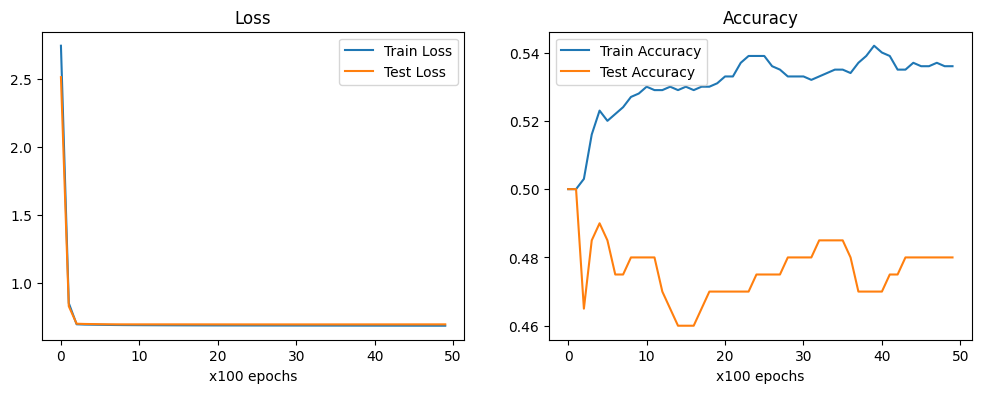

In [22]:
parameters = neural_network2(
    X_train_flat, y_train, X_test_flat, y_test,
    [X_train_flat.shape[0], 16, 16, 1],
    learning_rate=0.01, epoch=5000
)

Training accuracy climbs, but test accuracy stalls. The **overfitting wall** again.

Adding more layers doesn't solve it:
- More depth = more capacity
- More capacity without discipline = more memorization

> *"Is this a problem with the data, the model, or the training?"*
>
> Here, it's **all three**.

---

## What You've Built

You generalized five functions — and now you can build a network of **any depth**:

| Function | Episode VI | Episode VII |
|----------|-----------|------------|
| `initialisation` | 3 args (`n0, n1, n2`) | 1 list `dimensions` |
| `forward_propagation` | 4 hardcoded lines | loop over L layers |
| `back_propagation` | 6 hardcoded lines | backward loop |
| `update` | 4 subtractions | loop over L layers |
| `predict` | same | same |

The code for a 2-layer network and a 100-layer network is **the same**.

> *"You don't need a bigger codebase. You need a smarter one."*

---

## Share This Notebook

If this notebook helped you, share it:

- **GitHub**: [Deep-Learning-from-Scratch](https://github.com/Pchambet/Deep-Learning-from-Scratch)
- **LinkedIn**: [Pierre Chambet](https://www.linkedin.com/in/pierre-chambet/)

**Next episode**: We teach the network discipline — better activations, regularization, and smarter optimization.